# Figure S3 - recurrence, background spread, and timing (true genealogy)

Built from the true simulation genealogies (`run-out.branches`). One grid row per *established*-origin threshold (clade retains at least `THRESHOLDS` = 1, 10, 20 sampled infections). Column 1: origin-count CDF -- recurrence gets rarer as the threshold tightens (faint = per run, bold = selected). Columns 2/3: for each recurrent epitope substitution, the minimum background AA distance and minimum birth-time gap between its independent origins -- when recurrence does happen, the origins are genetically and temporally far apart. Box-and-strip, pooled over the candidate runs.

## Imports and parameters

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

HERE = Path.cwd()
sys.path.append(str(HERE.parent / 'scripts'))

from plot_truetree_homoplasy import build_pooled_threshold_grid
from plot_mutation_homoplasy import REPRESENTATIVE_RUN
from antigentools.supplement_style import apply_supplement_style

apply_supplement_style()

BATCH = '2026-07-04-reviewer-runs'
AGG_DIR = HERE.parent / 'results' / 'aggregated' / BATCH
CAND_PATH = HERE.parent / 'data' / BATCH / 'antigen-outputs' / 'candidate_runs.csv'
FIG_DIR = HERE.parent.parent / 'antigen-tex' / 'reviews' / 'round1' / 'figures'
FIG_PREFIX = 'figureS3_truetree_homoplasy'

# One grid row per established-lineage threshold; a stricter cutoff isolates the
# lineages variant assignment operates on and makes the recurrence-is-rare
# signal sharper.
THRESHOLDS = [1, 10, 20]
print(f'grid rows at >= {THRESHOLDS} sampled infections')

grid rows at >= [1, 10, 20] sampled infections


## Load the sweep output and restrict to the flu-like candidate runs

In [2]:
recurrence = pd.read_csv(AGG_DIR / 'truetree_recurrence_by_run.csv')
origin_counts = pd.read_csv(AGG_DIR / 'truetree_origin_counts_by_run.csv')
spread = pd.read_csv(AGG_DIR / 'truetree_origin_spread_by_run.csv')

cand = pd.read_csv(CAND_PATH)


def config_from_path(p):
    m = re.search(r'simulations/([^/]+)/run_', p)
    assert m is not None, f'cannot parse config from candidate path: {p!r}'
    return m.group(1)


cand['config'] = cand['path'].map(config_from_path)
cand_keys = set(zip(cand['config'], cand['run'].astype(int)))


def keep_candidates(df, label):
    keys = list(zip(df['config'], df['run'].astype(int)))
    kept = df[[k in cand_keys for k in keys]].copy()
    assert not kept.empty, f'no candidate runs survived the join for {label}'
    print(f'{label}: {len(kept)} rows from {kept.groupby(["config", "run"]).ngroups} candidate runs')
    return kept


recurrence = keep_candidates(recurrence, 'per-run recurrence')
origin_counts = keep_candidates(origin_counts, 'origin-count ECDF')
spread = keep_candidates(spread, 'origin spread')

for name, df in [('origin_counts', origin_counts), ('spread', spread)]:
    missing = [t for t in THRESHOLDS if t not in set(df['min_progeny'])]
    assert not missing, f'{name} missing thresholds {missing} of {sorted(set(df["min_progeny"]))}'

per-run recurrence: 45 rows from 45 candidate runs
origin-count ECDF: 2707 rows from 45 candidate runs


origin spread: 55882 rows from 45 candidate runs


## Figure S3

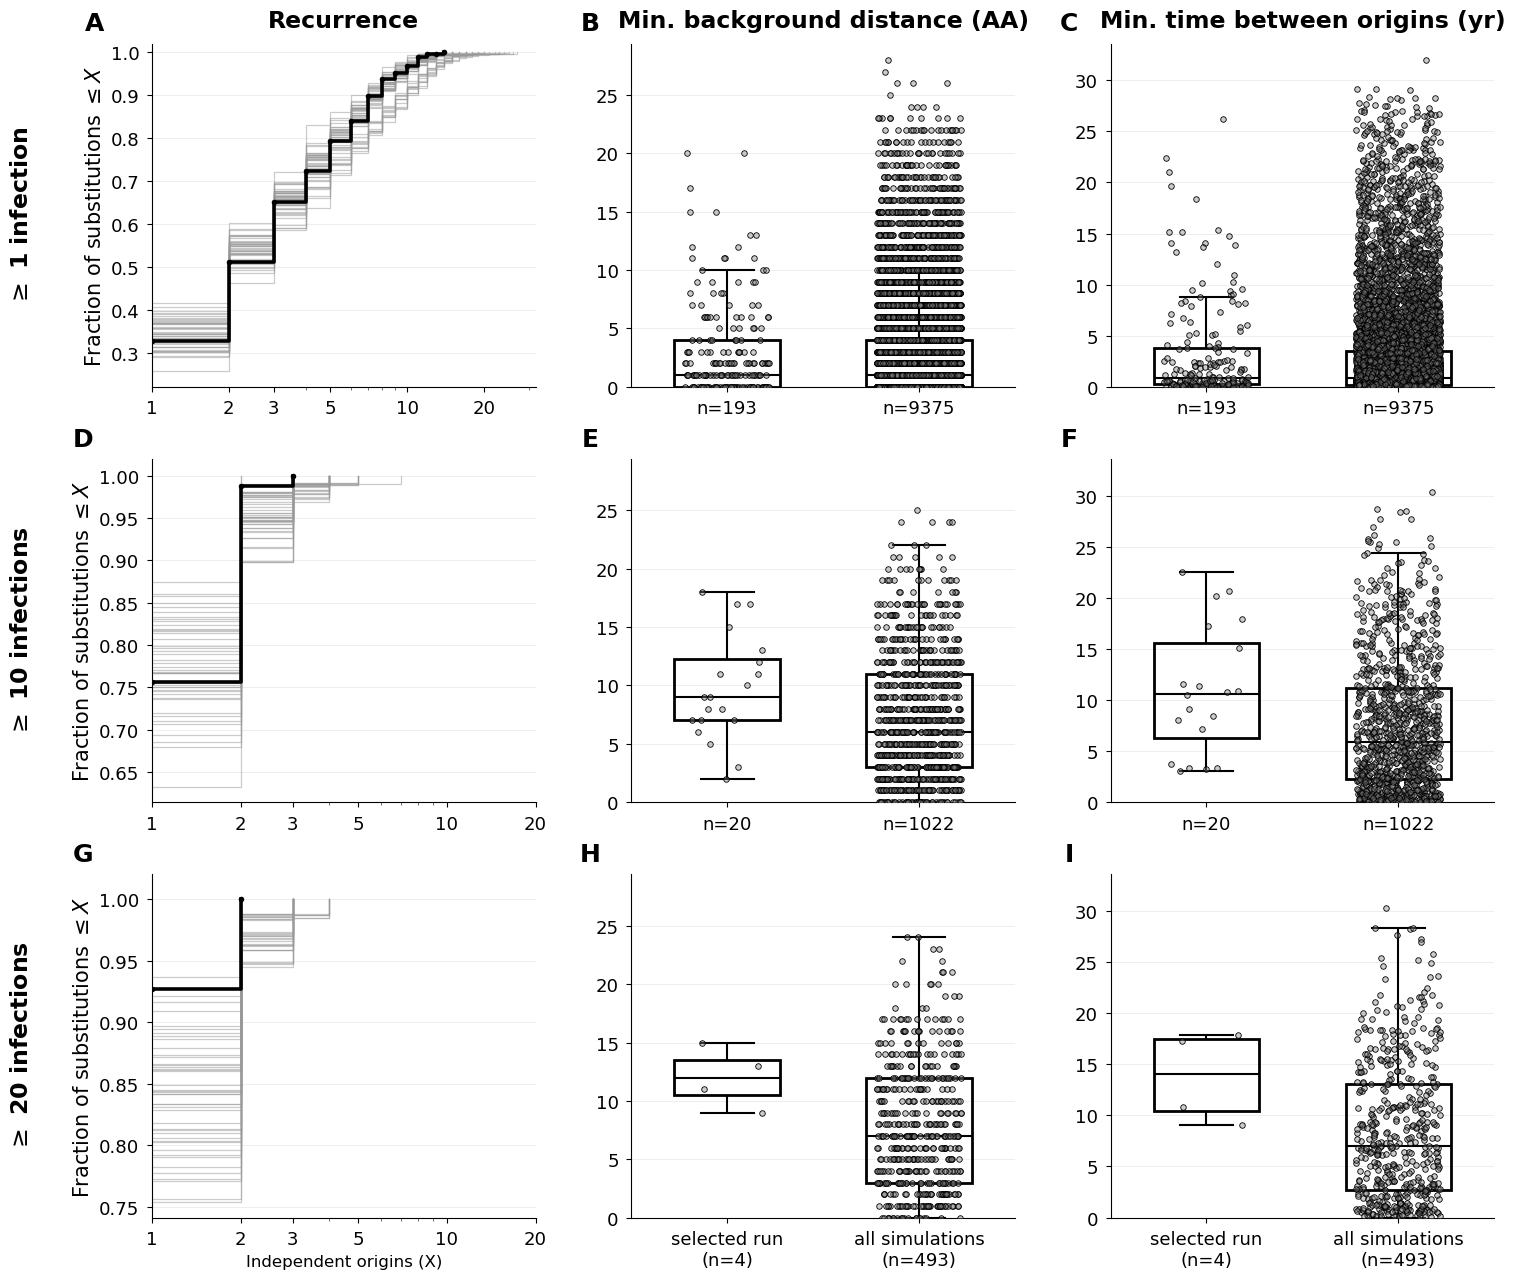

In [3]:
fig = build_pooled_threshold_grid(origin_counts, spread, REPRESENTATIVE_RUN, THRESHOLDS)
plt.show()

In [4]:
FIG_DIR.mkdir(parents=True, exist_ok=True)
for suffix in ('pdf', 'png'):
    path = FIG_DIR / f'{FIG_PREFIX}.{suffix}'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Wrote {path}')

Wrote /Users/zo/projects/research/antigen-tex/reviews/round1/figures/figureS3_truetree_homoplasy.pdf


Wrote /Users/zo/projects/research/antigen-tex/reviews/round1/figures/figureS3_truetree_homoplasy.png


## Numbers (pooled across candidate runs)

In [5]:
for thr in THRESHOLDS:
    est = spread[spread['min_progeny'] == thr]
    print(f'--- established at >= {thr} sampled infections ---')
    for is_epi, name in [(True, 'epitope'), (False, 'non_epitope')]:
        s = est[est['is_epitope'] == is_epi]
        print(f'{name:12s} n={len(s):5d}  '
              f'min background dist AA: median {s["min_background_distance_aa"].median():.1f}  '
              f'min gap yr: median {s["min_birthtime_gap_years"].median():.1f}')

--- established at >= 1 sampled infections ---
epitope      n= 9375  min background dist AA: median 1.0  min gap yr: median 0.8
non_epitope  n=32276  min background dist AA: median 5.0  min gap yr: median 4.3
--- established at >= 10 sampled infections ---
epitope      n= 1022  min background dist AA: median 6.0  min gap yr: median 5.9
non_epitope  n=  119  min background dist AA: median 8.0  min gap yr: median 9.2
--- established at >= 20 sampled infections ---
epitope      n=  493  min background dist AA: median 7.0  min gap yr: median 7.0
non_epitope  n=   24  min background dist AA: median 8.0  min gap yr: median 8.4
